In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

from utils import *

from scipy.optimize import curve_fit

In [2]:
NB = 100                              # Number of modes

g = 1.8                             # Strength of the spin hamiltonian


beta = 10                           # Inverse temperature

omega_c = .2
omega_max = 1
lam = .5

ss = [0.5,1,1.5]

dt = 0.01
Nt = 500

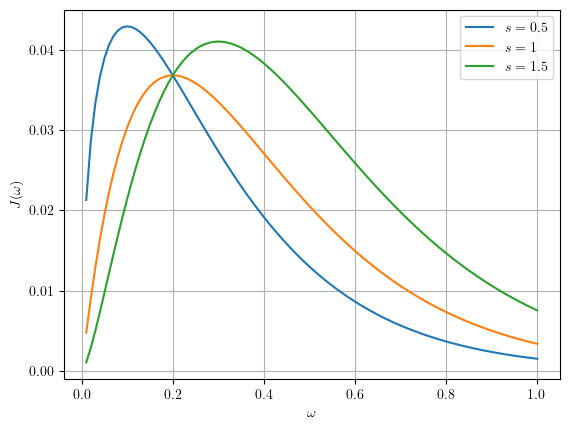

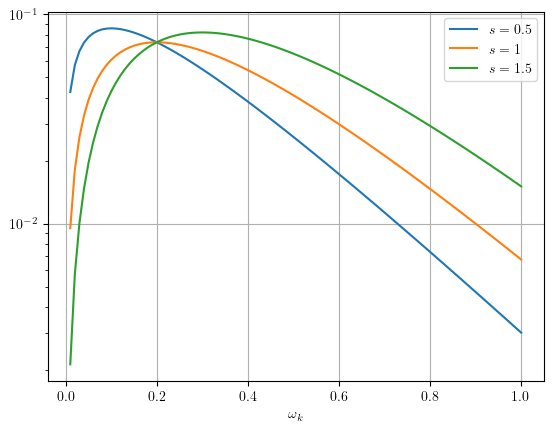

In [3]:
omega_k = omega_max*np.arange(1,NB+1)/NB 


lamss = []

plt.figure()
for s in ss:
    J_omega = lam/(omega_c**(s-1)) *omega_k**s *np.exp(-omega_k/omega_c)
    lamss.append(np.sqrt(J_omega))
    plt.plot(omega_k,J_omega,label=r'$s='+str(s)+r'$')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$J(\omega)$')
plt.grid()
plt.legend()
plt.show()

plt.figure()
a_ks =[] 
for j, lam_k in enumerate(lamss):
    x = beta*omega_k
    a_k = 2*np.abs(lam_k)**2 * (np.exp(x)+1)/(np.exp(x)+1)
    a_ks.append(a_k)
    plt.plot(omega_k,a_k, label=r'$s='+str(ss[j])+r'$')
plt.xlabel(r'$\omega_k$')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()


In [4]:
H_S = g/2*Z()

In [5]:
ts = np.arange(Nt+1)*dt

In [6]:
def gamma(t,j):
    res = np.zeros_like(t)
    for k in range(NB):
        res =res + a_ks[j][k]*(1-np.cos(omega_k[k]*t))/t
    return res

def xi(t,j):
    res = np.zeros_like(t)
    for k in range(NB):
        res = res + a_ks[j][k]*omega_k[k]*(np.sin(omega_k[k]*t))
    return res

1.7977478150814443
0.43296523475500986



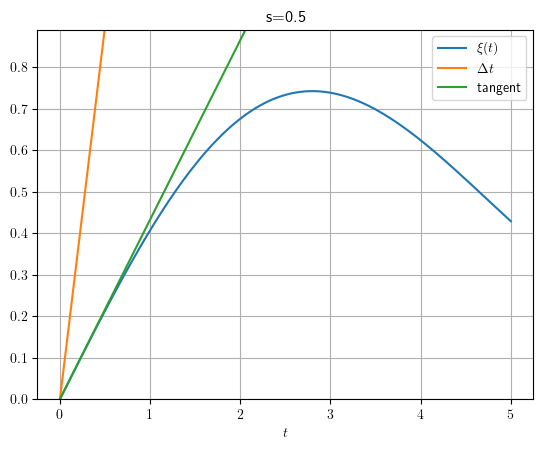

0.8856334037486263
0.7089328730810581



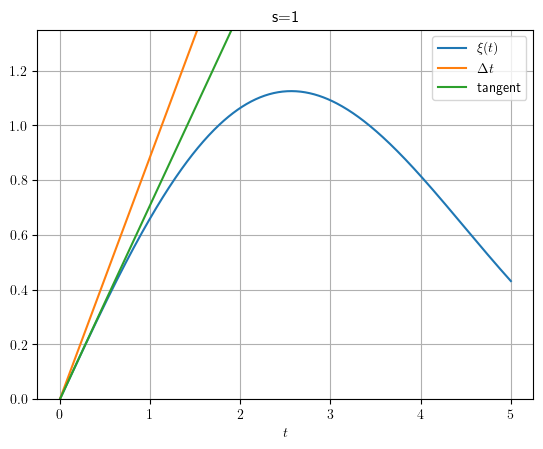

0.5502371770132612
1.2163111572157994



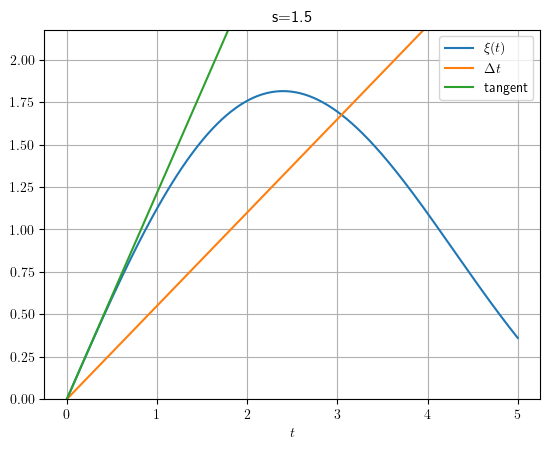

In [7]:
phis = []
for j in range(len(ss)):
    phi = 0
    for k in range(NB):
        phi += 2 * np.abs(lamss[j][k])**2/(np.exp(beta*omega_k[k])-1)
    print(phi)
    phis.append(phi)

    tmp = 0
    for k in range(NB):
        tmp += a_ks[j][k]*omega_k[k]**2
    print(tmp)
    print()

    plt.figure()
    plt.plot(ts,xi(ts,j),label=r'$\xi(t)$')
    plt.plot(ts,phi*ts, label=r'$\Delta t$')
    plt.plot(ts,tmp*ts, label=r'tangent')
    plt.grid()
    plt.ylim([1.2*np.min(xi(ts,j)),1.2*np.max(xi(ts,j))])
    plt.title('s='+str(ss[j]))
    plt.legend()
    plt.xlabel(r'$t$')
    plt.show()

## Simulation

In [8]:
rho_0 = np.ones([2,2])/2
x_0 = vec(rho_0).reshape([4,])

In [9]:
Lc_H = Lindblad_to_matrix(H_S,[])
Lc_D = Lindblad_to_matrix(H_S*0,[Z()])

multi_rho_Ss = []

for j in range(len(ss)):
    def fun(t,x):
        xdot = (Lc_H + xi(t,j)* Lc_D) @ x
        return xdot

    result = sp.integrate.solve_ivp(fun,[0,(Nt+1)*dt], x_0, t_eval=ts)

    rho_Ss = []
    for j in range(result.y.shape[1]):
        rho_Ss.append(unvec(result.y[:,j].reshape([4,])))
    rho_Ss = np.array(rho_Ss)
    multi_rho_Ss.append(rho_Ss)

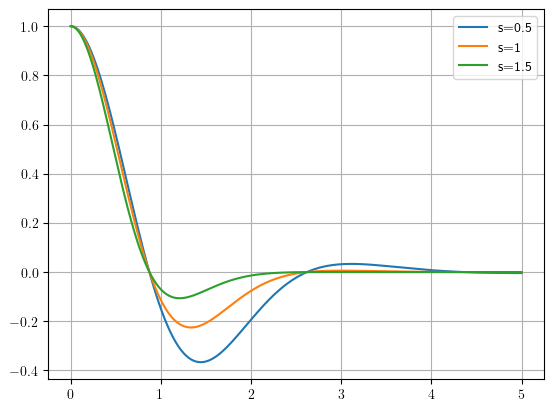

In [10]:
plt.figure()

for j in range(len(ss)):
    xs = np.real(np.trace(multi_rho_Ss[j]@X(),axis1=1,axis2=2))
    plt.plot(ts,xs, label='s='+str(ss[j]))
    
plt.grid()
plt.legend()
plt.show()

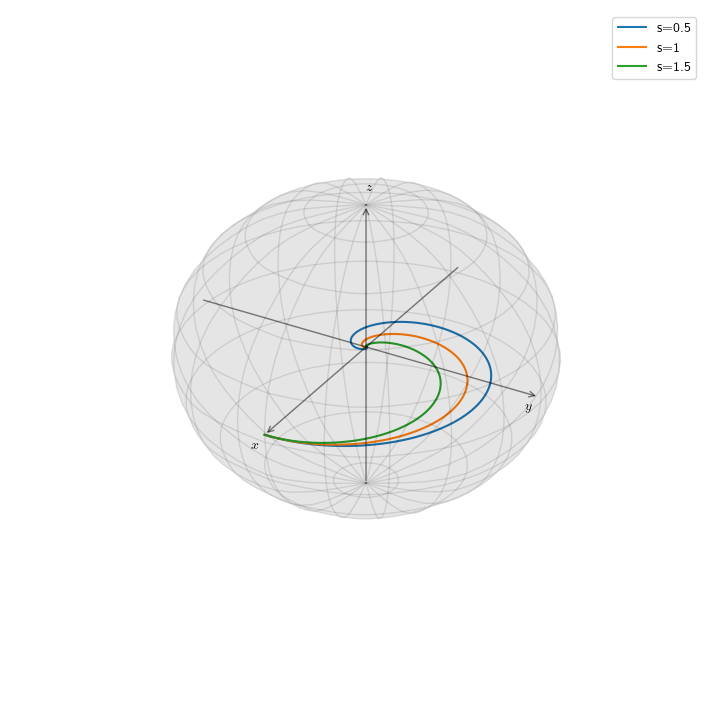

In [11]:
fig, ax = plot_bloch_shpere()
for j in range(len(ss)):
    xs = np.real(np.trace(multi_rho_Ss[j]@X(),axis1=1,axis2=2))
    ys = np.real(np.trace(multi_rho_Ss[j]@Y(),axis1=1,axis2=2))
    zs = np.real(np.trace(multi_rho_Ss[j]@Z(),axis1=1,axis2=2))
    ax.plot(np.real(xs),np.real(ys),np.real(zs), alpha=1, label='s='+str(ss[j]))
plt.legend()
plt.show()

### Our approximation

In [12]:
multi_mu_s = []
for j in range(len(ss)):
    def fun_approx(t,x):
        xdot = (Lc_H + t*phis[j]* Lc_D) @ x
        return xdot

    result = sp.integrate.solve_ivp(fun_approx,[0,(Nt+1)*dt], x_0, t_eval=ts)

    mu_s = []
    for j in range(result.y.shape[1]):
        mu_s.append(unvec(result.y[:,j].reshape([4,])))
    mu_s = np.array(mu_s)
    multi_mu_s.append(mu_s)

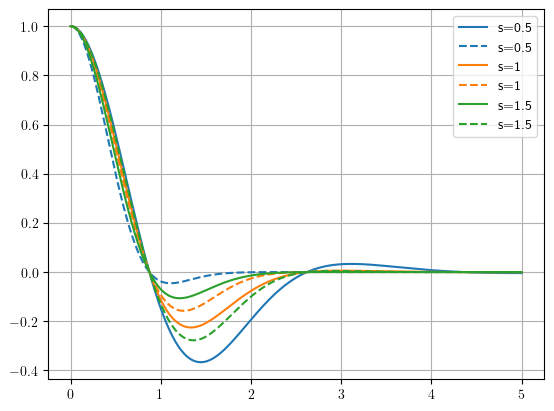

In [13]:
plt.figure()
for j in range(len(ss)):
    xs_a = np.real(np.trace(multi_mu_s[j]@X(),axis1=1,axis2=2))
    xs = np.real(np.trace(multi_rho_Ss[j]@X(),axis1=1,axis2=2))
    lines=plt.plot(ts,xs, label = 's='+str(ss[j]) )
    linecolor = lines[0].get_color()
    plt.plot(ts,xs_a, '--', label = 's='+str(ss[j]), color=linecolor)
plt.legend()
plt.grid()
plt.show()

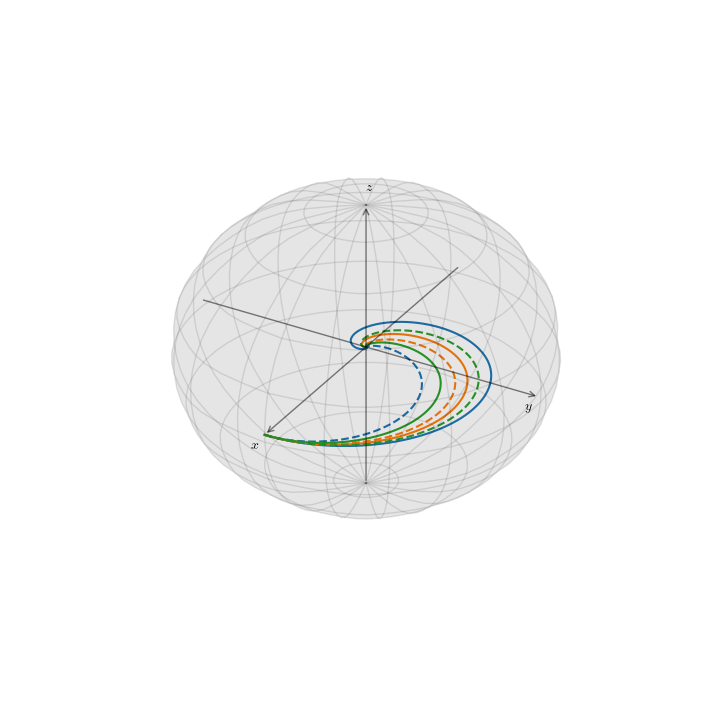

In [14]:
fig, ax = plot_bloch_shpere()
for j in range(len(ss)):
    xs = np.real(np.trace(multi_rho_Ss[j]@X(),axis1=1,axis2=2))
    ys = np.real(np.trace(multi_rho_Ss[j]@Y(),axis1=1,axis2=2))
    zs = np.real(np.trace(multi_rho_Ss[j]@Z(),axis1=1,axis2=2))
    xs_a = np.real(np.trace(multi_mu_s[j]@X(),axis1=1,axis2=2))
    ys_a = np.real(np.trace(multi_mu_s[j]@Y(),axis1=1,axis2=2))
    zs_a = np.real(np.trace(multi_mu_s[j]@Z(),axis1=1,axis2=2))
    lines = ax.plot(np.real(xs),np.real(ys),np.real(zs), alpha=1, label = 's='+str(ss[j]))
    linecolor = lines[0].get_color()
    ax.plot(np.real(xs_a),np.real(ys_a),np.real(zs_a), '--', alpha=1, label = 's='+str(ss[j]), color=linecolor )
plt.show()

[0.00042] [[4.56324e-08]]
[7.94511e-05] [[1.96086e-09]]
[0.00011] [[1.25327e-08]]


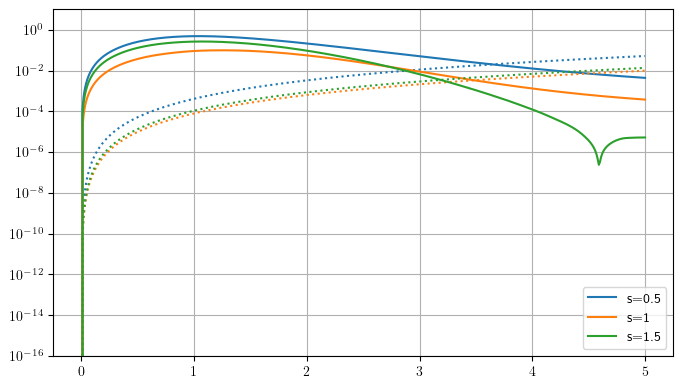

In [15]:
def distance(rho,tau):
    A = rho-tau
    return np.real(np.trace(sp.linalg.sqrtm(A.H@A)))

plt.figure(figsize=(16/2,9/2))

for j in range(len(ss)):
    error = []
    for k in range(rho_Ss.shape[0]):
        error.append(distance(multi_rho_Ss[j][k,:,:],multi_mu_s[j][k,:,:]))


    lines = plt.plot(ts,error,'-', label='s='+str(ss[j]))
    def func(x, a):
            return a * x**(3)

    popt, pcov = curve_fit(func, ts, error)
    print(popt, pcov)
    linecolor = lines[0].get_color()
    plt.plot(ts,func(ts,popt),':', color=linecolor)


plt.grid()
plt.yscale('log')
plt.ylim([1e-16,10])
plt.legend()
plt.show()

### Coarse-grained dynamics

In [16]:
multi_mu_s_cg = []
for j in range(len(ss)):
    tau = 2/omega_c
    def fun_approx(t,x):
        xdot = (Lc_H + gamma(tau,j)* Lc_D) @ x
        return xdot

    result = sp.integrate.solve_ivp(fun_approx,[0,(Nt+1)*dt], x_0, t_eval=ts)

    mu_s = []
    for j in range(result.y.shape[1]):
        mu_s.append(unvec(result.y[:,j].reshape([4,])))
    mu_s = np.array(mu_s)
    multi_mu_s_cg.append(mu_s)

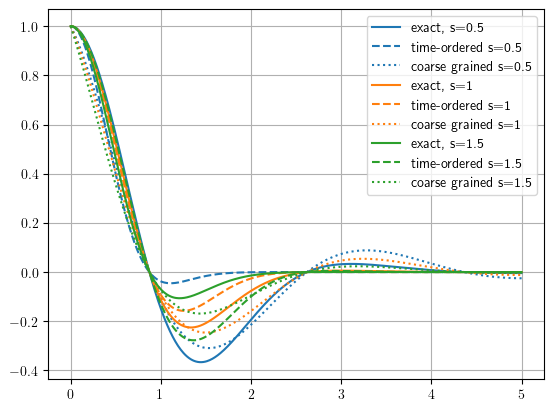

In [32]:
data = [ts]

plt.figure()
for j in range(len(ss)):
    xs = np.real(np.trace(multi_rho_Ss[j]@X(),axis1=1,axis2=2))
    xs_a = np.real(np.trace(multi_mu_s[j]@X(),axis1=1,axis2=2))
    xs_a_cg = np.real(np.trace(multi_mu_s_cg[j]@X(),axis1=1,axis2=2))
    data.extend([xs,xs_a,xs_a_cg])
    lines=plt.plot(ts,xs, label = 'exact, s='+str(ss[j]))
    linecolor = lines[0].get_color()
    plt.plot(ts,xs_a, '--', label = 'time-ordered s='+str(ss[j]), color=linecolor)
    plt.plot(ts,xs_a_cg, ':', label = 'coarse grained s='+str(ss[j]), color=linecolor)
plt.legend()
plt.grid()
plt.show()

header = ['t']
for j in range(len(ss)):
    header.extend(['ex'+str(j), 'to'+str(j), 'cg'+str(j) ])

df = pd.DataFrame(np.array(data).T, columns=header)
df.to_csv('../data/dephasing_spin_boson.csv',index=False)

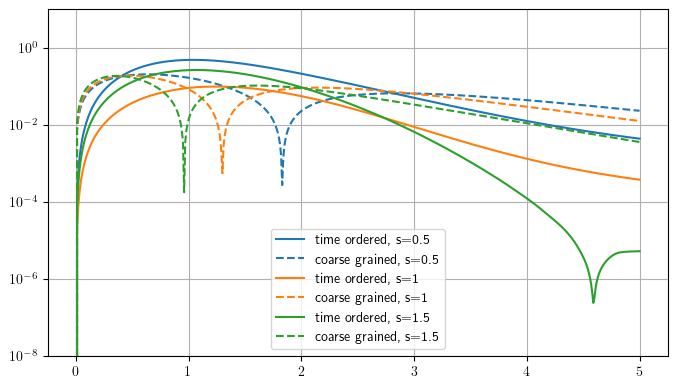

In [33]:
def distance(rho,tau):
    A = rho-tau
    return np.real(np.trace(sp.linalg.sqrtm(A.H@A)))

plt.figure(figsize=(16/2,9/2))

data = [ts]

for j in range(len(ss)):
    error = []
    for k in range(rho_Ss.shape[0]):
        error.append(distance(multi_rho_Ss[j][k,:,:],multi_mu_s[j][k,:,:]))

    data.append(error)

    lines = plt.plot(ts,error,'-', label=' time ordered, s='+str(ss[j]))
    linecolor = lines[0].get_color()

    error = []
    for k in range(rho_Ss.shape[0]):
        error.append(distance(multi_rho_Ss[j][k,:,:],multi_mu_s_cg[j][k,:,:]))
    
    data.append(error)

    plt.plot(ts,error,'--', label=' coarse grained, s='+str(ss[j]) , color=linecolor)

    # def func(x, a):
    #         return a * x**(3)

    # popt, pcov = curve_fit(func, ts, error)
    # print(popt, pcov)
    # linecolor = lines[0].get_color()
    # plt.plot(ts,func(ts,popt),':', color=linecolor)


plt.grid()
plt.yscale('log')
plt.ylim([1e-8,10])
plt.legend()
plt.show()

header = ['t']
for j in range(len(ss)):
    header.extend(['eto'+str(j), 'ecg'+str(j) ])

df = pd.DataFrame(np.array(data).T, columns=header)
df.to_csv('../data/error_dephasing_spin_boson.csv',index=False)